# Boolean Networks - Computer Practical

Focus: Network dynamics, state spaces, and predictive modeling

## Instructions for Students
- 🟢 **Code**: Code provided - run and observe
- 🟡 **TODO**: You need to complete these - look for TODO comments
- ❓ **Question**: Analysis questions you need to answer


In [1]:
# 🟢 Setup and Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import seaborn as sns
from itertools import product
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

### What are boolean networks?
Boolean networks are mathematical models where:
*   Each node has a binary state: ON (1) or OFF (0)
*   Nodes update based on Boolean rules (AND, OR, NOT)

### Why should you use Boolean Networks?
*   Handle discrete/categorical data naturally  
*   Model complex systems with simple rules
*   Find stable patterns (attractors) in data
*   Test 'what-if' scenarios (perturbation analysis)







---

### Helper functions to create a Boolean network
Run the following code snippet so the basic functions are available.

In [2]:
# 🟢 Helper class to build and simulate boolean network

class BooleanNetwork:
    def __init__(self, node_names):
        self.nodes = {name: 0 for name in node_names}
        self.rules = {}
        self.history = []
        self.graph = nx.DiGraph()  # NetworkX graph for visualization

        # Add nodes to NetworkX graph
        self.graph.add_nodes_from(node_names)

    def add_rule(self, target_node, rule_function, rule_description=""):
        """
        Add Boolean rule for a node

        Args:
            target_node: Node to update
            rule_function: Function that takes current state dict and returns True/False
            rule_description: Human-readable description
        """
        self.rules[target_node] = {
            'function': rule_function,
            'description': rule_description
        }

    def set_state(self, **kwargs):
        """Set states of specific nodes"""
        for node, value in kwargs.items():
            if node in self.nodes:
                self.nodes[node] = int(bool(value))

    def get_state_vector(self):
        """Get current state as list in sorted order"""
        return [self.nodes[node] for node in sorted(self.nodes.keys())]

    def update_synchronous(self):
        """Update all nodes simultaneously"""
        new_state = {}
        for node in self.nodes:
            if node in self.rules:
                new_state[node] = int(self.rules[node]['function'](self.nodes))
            else:
                new_state[node] = self.nodes[node]  # No rule = no change

        self.nodes = new_state
        self.history.append(self.get_state_vector())

    def simulate(self, steps=10, record_history=True):
        """Run simulation"""
        if record_history:
            self.history = [self.get_state_vector()]

        for step in range(steps):
            self.update_synchronous()

            # Check for steady state
            if len(self.history) >= 2 and self.history[-1] == self.history[-2]:
                print(f"   Reached steady state after {step+1} steps")
                break

        return np.array(self.history)



---



## Part 1: Simple 3-node Boolean network

Let's first play with a simple 3-node example network

In [3]:
# 🟢 Helper class to build and simulate boolean network

print("Demo: Creating a simple 3-node Boolean network")

demo = BooleanNetwork(['A', 'B', 'C'])

# Add rules with clear descriptions
demo.add_rule('A', lambda state: not state['C'], "A = NOT C")
demo.add_rule('B', lambda state: state['A'] and state['C'], "B = A AND C")
demo.add_rule('C', lambda state: state['A'] or state['B'], "C = A OR B")

print("Rules:")
for node, rule_info in demo.rules.items():
    print(f"  {node}: {rule_info['description']}")

Demo: Creating a simple 3-node Boolean network
Rules:
  A: A = NOT C
  B: B = A AND C
  C: C = A OR B


❓ **Question**: How does the system look like? Draw the directed network structure on paper based on the logical rules!

In [4]:
# 🟢 Test simulation
demo.set_state(A=1, B=0, C=0)
print(f"\nStarting state: A=1, B=0, C=0")

trajectory = demo.simulate(steps=6)
print("Trajectory:")
for i, state in enumerate(trajectory):
    state_dict = {node: state[j] for j, node in enumerate(sorted(demo.nodes.keys()))}
    print(f"  Step {i}: A={state_dict['A']}, B={state_dict['B']}, C={state_dict['C']}")


Starting state: A=1, B=0, C=0
Trajectory:
  Step 0: A=1, B=0, C=0
  Step 1: A=1, B=0, C=1
  Step 2: A=0, B=1, C=1
  Step 3: A=0, B=0, C=1
  Step 4: A=0, B=0, C=0
  Step 5: A=1, B=0, C=0
  Step 6: A=1, B=0, C=1


❓ **Question**: What pattern do you observe?

*   Reaches stable state
*   Oscillates forever  !!!!!!!  
*   Grows exponentially
*   Random behavior




---



## Part 2: Simplified cell regulatory network

🧬 Biological context

Cells make binary decisions:
* GROW: Divide and multiply (good for healing, bad if uncontrolled)
* DIE: Self-destruct (protective mechanism, prevents cancer)
* REST: Stay inactive (safe default state)

Key molecular switches (think: binary variables):
* DNA_damage: External damage signal (input variable)
* p53: "Tumor suppressor" - master safety switch that detects problems
* MYC: "Oncogene" - growth promoter that drives cell division
* CDK2: Cell division machinery that executes growth
* MDM2: "p53 inhibitor" - blocks p53 function (cancer exploit!)
* p21: "Cell cycle brake" - stops division when problems detected
* Growth/Death: Final binary decisions (outputs)

In [5]:
# 🟢 Create the regulatory network
nodes = ['DNA_damage', 'p53', 'MYC', 'CDK2', 'MDM2', 'p21', 'Growth', 'Death']
network = BooleanNetwork(nodes)

# Define Boolean rules (based on real biology, simplified)
network.add_rule('DNA_damage', lambda s: s['DNA_damage'], "DNA_damage = INPUT (constant)")
network.add_rule('p21', lambda s: s['p53'], "p21 = p53")
network.add_rule('MYC', lambda s: (not s['p53']) and (not s['p21']), "MYC = (NOT p53) AND (NOT p21)")
network.add_rule('CDK2', lambda s: s['MYC'] and (not s['p21']) and (not s['p53']), "CDK2 = MYC AND (NOT p21) AND (NOT p53)")
network.add_rule('MDM2', lambda s: s['MYC'], "MDM2 = MYC")
network.add_rule('p53', lambda s: s['DNA_damage'] and not s['MDM2'], "p53 = DNA_damage AND (NOT MDM2)")
network.add_rule('Growth',lambda s: s['CDK2'] and s['MYC'] and (not s['p53']), "Growth = CDK2 AND MYC AND (NOT p53)")
network.add_rule('Death', lambda s: s['p53'] and s['DNA_damage'] and (not s['Growth']), "Death = p53 AND DNA_damage AND (NOT Growth)")

print("Rules:")
for node, rule_info in network.rules.items():
    print(f" {rule_info['description']}")

Rules:
 DNA_damage = INPUT (constant)
 p21 = p53
 MYC = (NOT p53) AND (NOT p21)
 CDK2 = MYC AND (NOT p21) AND (NOT p53)
 MDM2 = MYC
 p53 = DNA_damage AND (NOT MDM2)
 Growth = CDK2 AND MYC AND (NOT p53)
 Death = p53 AND DNA_damage AND (NOT Growth)


❓ **Question**: How does the system look like? Draw the directed network structure on paper based on the logical rules!

For each molecule, add a short description:
- e.g. MYC is suppressed by both p53 and p21
- p21 - activated by p53, inhbited by MYC and CDK2
- CDK2 - CDK2 is activated by MYC and suppressed by p21 and p53. It promotes Growth.
- MDM2 - MDM2 is activated by MYC and inhibits p53.
- p53 - p53 is activated by DNA damage and suppressed by MDM2. It activates p21 and Death, while inhibiting MYC, CDK2, and Growth.
- DNA damage - external input that activates p53 and contributes to Death.
- Growth - Growth requires both MYC and CDK2 and is suppressed by p53.
- Death - Death requires p53 and DNA damage and is prevented when Growth is active

### Predict the outcomes
❓ **Question**: Before running simulations, make your predictions:

Scenarios:
*   Healthy Cell: `{'DNA_damage': 0, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}`
*   Stressed Cell (Repairable): `{'DNA_damage': 1, 'p53': 0, 'MYC': 0, 'CDK2': 0,'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}`
*   Oncogene Hijacked Cell: `{'DNA_damage': 0, 'p53': 0, 'MYC': 1, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}`

For each scenario, decide on the final growth, death and p53 state (0 or 1).



In [6]:
# 🟡 Example code for healthy cell below, adapt to also run Stressed Cell and Oncogene Hijacked Cell scenarios

scenarios = {
    'Healthy Cell': {'DNA_damage': 0, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Stressed Cell': { 'DNA_damage': 1, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Oncogene Hijacked Cell': { 'DNA_damage': 0, 'p53': 0, 'MYC': 1, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}
}

results = {}

# Run healthy cell scenario
s = "Healthy Cell"
initial_state = scenarios[s]
network.set_state(**initial_state)
trajectory = network.simulate(steps=8)
results[s] = trajectory

final_state = trajectory[-1]
node_names = sorted(network.nodes.keys())
final_dict = {node: final_state[i] for i, node in enumerate(node_names)}

print(f"   {s}: Final state: Growth={final_dict['Growth']}, Death={final_dict['Death']}, p53={final_dict['p53']}")


# Stressed cell
# Stressed cell scenario
s = "Stressed Cell"
initial_state = scenarios[s]
network.set_state(**initial_state)
trajectory = network.simulate(steps=8)
results[s] = trajectory

final_state = trajectory[-1]
node_names = sorted(network.nodes.keys())
final_dict = {node: final_state[i] for i, node in enumerate(node_names)}

print(f"   {s}: Final state: Growth={final_dict['Growth']}, Death={final_dict['Death']}, p53={final_dict['p53']}")


# Oncogene Hijacked Cell scenario
s = "Oncogene Hijacked Cell"
initial_state = scenarios[s]
network.set_state(**initial_state)
trajectory = network.simulate(steps=8)
results[s] = trajectory

final_state = trajectory[-1]
node_names = sorted(network.nodes.keys())
final_dict = {node: final_state[i] for i, node in enumerate(node_names)}

print(f"   {s}: Final state: Growth={final_dict['Growth']}, Death={final_dict['Death']}, p53={final_dict['p53']}")

   Reached steady state after 4 steps
   Healthy Cell: Final state: Growth=1, Death=0, p53=0
   Reached steady state after 6 steps
   Stressed Cell: Final state: Growth=0, Death=1, p53=1
   Reached steady state after 3 steps
   Oncogene Hijacked Cell: Final state: Growth=1, Death=0, p53=0


In [7]:
#Function for running scenarious 
def run_scenarios(network, scenarios, mutation):
    results = {}

    for s in scenarios:
        initial_state = scenarios[s]

        network.set_state(**initial_state)

        trajectory = network.simulate(steps=8)

        results[s] = trajectory

        final_state = trajectory[-1]

        node_names = sorted(network.nodes.keys())

        # Convert final state into dictionary
        final_dict = {
            node: final_state[i]
            for i, node in enumerate(node_names)
        }

        # Print final result
        print(
            f"{s}: Final state: "
            f"Growth={final_dict['Growth']}, "
            f"Death={final_dict['Death']}, "
            f"{mutation}={final_dict[mutation]}"
        )

    return results

results_normal = run_scenarios(network, scenarios,'p53')

   Reached steady state after 4 steps
Healthy Cell: Final state: Growth=1, Death=0, p53=0
   Reached steady state after 6 steps
Stressed Cell: Final state: Growth=0, Death=1, p53=1
   Reached steady state after 3 steps
Oncogene Hijacked Cell: Final state: Growth=1, Death=0, p53=0


In [8]:
# MUTATION A: p53 KNOCKOUT

nodes = ['DNA_damage', 'p53', 'MYC', 'CDK2',
         'MDM2', 'p21', 'Growth', 'Death']

p53_KO_network = BooleanNetwork(nodes)

# Same rules as normal network
p53_KO_network.add_rule(
    'DNA_damage',
    lambda s: s['DNA_damage'],
    "DNA_damage = INPUT"
)

p53_KO_network.add_rule(
    'p21',
    lambda s: s['p53'],
    "p21 = p53"
)

p53_KO_network.add_rule(
    'MYC',
    lambda s: (not s['p53']) and (not s['p21']),
    "MYC = (NOT p53) AND (NOT p21)"
)

p53_KO_network.add_rule(
    'CDK2',
    lambda s: s['MYC'] and (not s['p21']) and (not s['p53']),
    "CDK2 = MYC AND (NOT p21) AND (NOT p53)"
)

p53_KO_network.add_rule(
    'MDM2',
    lambda s: s['MYC'],
    "MDM2 = MYC"
)

# Mutation A: p53 is always OFF
p53_KO_network.add_rule(
    'p53',
    lambda s: False,
    "p53 = BROKEN (always OFF)"
)

p53_KO_network.add_rule(
    'Growth',
    lambda s: s['CDK2'] and s['MYC'] and (not s['p53']),
    "Growth = CDK2 AND MYC AND (NOT p53)"
)

p53_KO_network.add_rule(
    'Death',
    lambda s: s['p53'] and s['DNA_damage'] and (not s['Growth']),
    "Death = p53 AND DNA_damage AND (NOT Growth)"
)

print("Mutation A network created")
results_A = run_scenarios(p53_KO_network, scenarios,'p53')

Mutation A network created
   Reached steady state after 4 steps
Healthy Cell: Final state: Growth=1, Death=0, p53=0
   Reached steady state after 4 steps
Stressed Cell: Final state: Growth=1, Death=0, p53=0
   Reached steady state after 3 steps
Oncogene Hijacked Cell: Final state: Growth=1, Death=0, p53=0


In [9]:
from collections import defaultdict
# ATTRACTOR ANALYSIS: p53 KNOCKOUT


attractors_A = []
basin_data_A = defaultdict(list)

max_steps = 15

node_names = sorted(p53_KO_network.nodes.keys())
n_nodes = len(node_names)

# Generate all 2^8 = 256 possible initial states
all_states = list(product([0, 1], repeat=n_nodes))

print(f"Testing all {len(all_states)} initial states...")


for initial_state in all_states:

    # Convert tuple into dictionary
    state_dict = {
        node_names[i]: initial_state[i]
        for i in range(n_nodes)
    }

    # Set initial state
    p53_KO_network.set_state(**state_dict)

    # Run simulation
    trajectory = p53_KO_network.simulate(
        steps=max_steps,
        record_history=True
    )

    # Check whether we reached a fixed point
    if len(trajectory) >= 2 and np.array_equal(
        trajectory[-1],
        trajectory[-2]
    ):

        final_state = tuple(
            int(x) for x in trajectory[-1]
        )

        # Add attractor if we haven't seen it before
        if final_state not in attractors_A:
            attractors_A.append(final_state)

        # Find attractor number
        att_idx = attractors_A.index(final_state)

        # Save which initial state led to this attractor
        basin_data_A[att_idx].append(initial_state)


print(f"\nFOUND {len(attractors_A)} ATTRACTORS")
#Sizes of the basins
print("\nBASIN SIZES:")

total_states = len(all_states)

for att_idx in range(len(attractors_A)):
    basin_size = len(basin_data_A[att_idx])
    percentage = (basin_size / total_states) * 100

    print(
        f"Attractor {att_idx + 1}: "
        f"{basin_size} states ({percentage:.1f}%)"
    )

Testing all 256 initial states...
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached stead

Attractor 2 leads to cancer-like state as it has DNA damage, but the cell continues to grow (and doesn't die)

| Network      | Healthy | Stressed | Oncogene | # Attractors | Cancer-like basin |
| ------------ | ------- | -------- | -------- | -----------: | ----------------: |
| Normal       | Growth  | Death    | Growth   |            3 |              3.1% |
| p53 Knockout | Growth  | Growth   | Growth   |            2 |             50.0% |

Table with comparison of normal states and states with p53 knockout


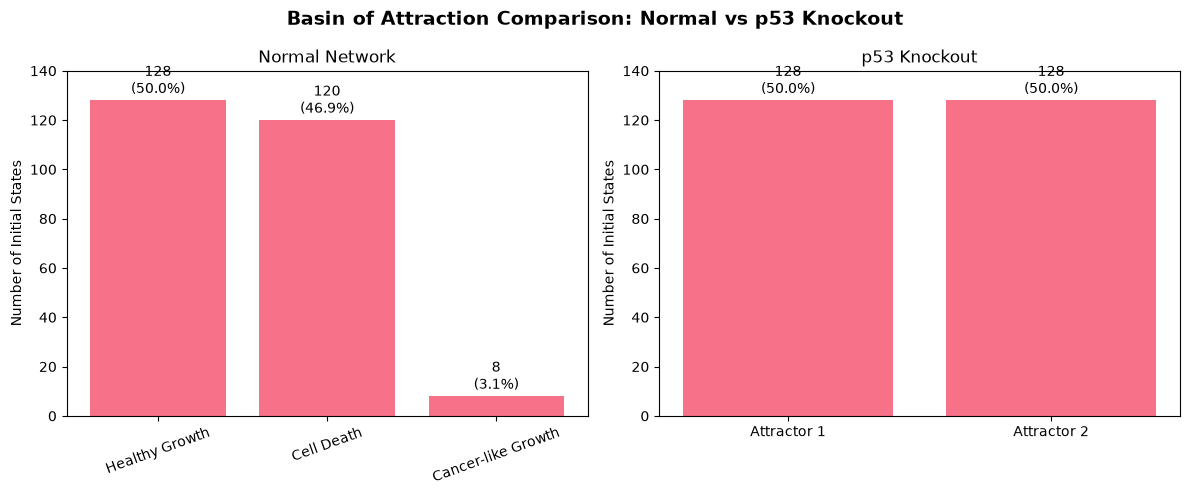

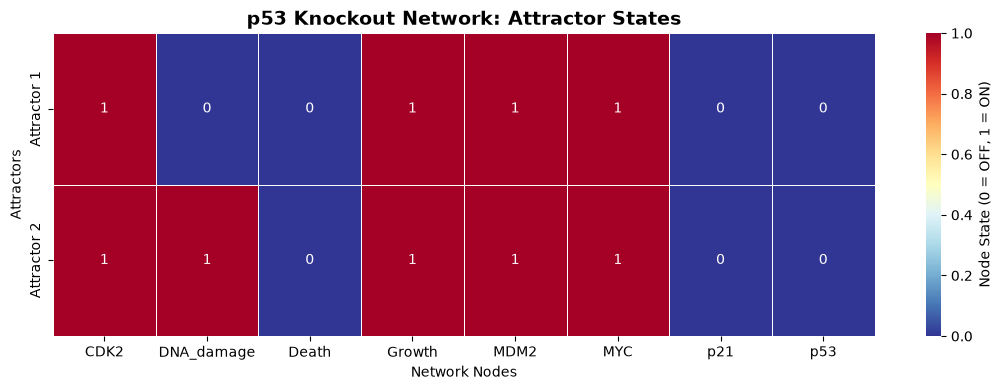

In [10]:
#charts for basin size comparison

normal_basin_sizes = [128, 120, 8]
p53_KO_basin_sizes = [
    len(basin_data_A[i])
    for i in range(len(attractors_A))
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normal networks
normal_labels = [
    'Healthy Growth',
    'Cell Death',
    'Cancer-like Growth'
]

axes[0].bar(normal_labels, normal_basin_sizes)

axes[0].set_title('Normal Network')
axes[0].set_ylabel('Number of Initial States')
axes[0].set_ylim(0, 140)

for i, value in enumerate(normal_basin_sizes):
    axes[0].text(
        i,
        value + 3,
        f'{value}\n({value / 256 * 100:.1f}%)',
        ha='center'
    )

axes[0].tick_params(axis='x', rotation=20)


# p53 knockout
KO_labels = [
    f'Attractor {i+1}'
    for i in range(len(attractors_A))
]

axes[1].bar(KO_labels, p53_KO_basin_sizes)

axes[1].set_title('p53 Knockout')
axes[1].set_ylabel('Number of Initial States')
axes[1].set_ylim(0, 140)

for i, value in enumerate(p53_KO_basin_sizes):
    axes[1].text(
        i,
        value + 3,
        f'{value}\n({value / 256 * 100:.1f}%)',
        ha='center'
    )

plt.suptitle(
    'Basin of Attraction Comparison: Normal vs p53 Knockout',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

#Knockout attractor heatmap

attractor_matrix_A = np.array([
    [int(x) for x in attractor]
    for attractor in attractors_A
])

plt.figure(figsize=(11, 4))

ax = sns.heatmap(
    attractor_matrix_A,
    xticklabels=node_names,
    yticklabels=[
        f'Attractor {i+1}'
        for i in range(len(attractors_A))
    ],
    cmap='RdYlBu_r',
    annot=True,
    fmt='d',
    linewidths=0.5,
    cbar_kws={
        'label': 'Node State (0 = OFF, 1 = ON)'
    }
)

plt.title(
    'p53 Knockout Network: Attractor States',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Network Nodes')
plt.ylabel('Attractors')

plt.tight_layout()
plt.show()

For the normal network only 3.1% of initial states lead to cancer-like growth states, while after p53 protein knockout exactly 50% of initial states lead to a cancel-like growth state of a cell. As p53 plays a role of cancer cell supression, 

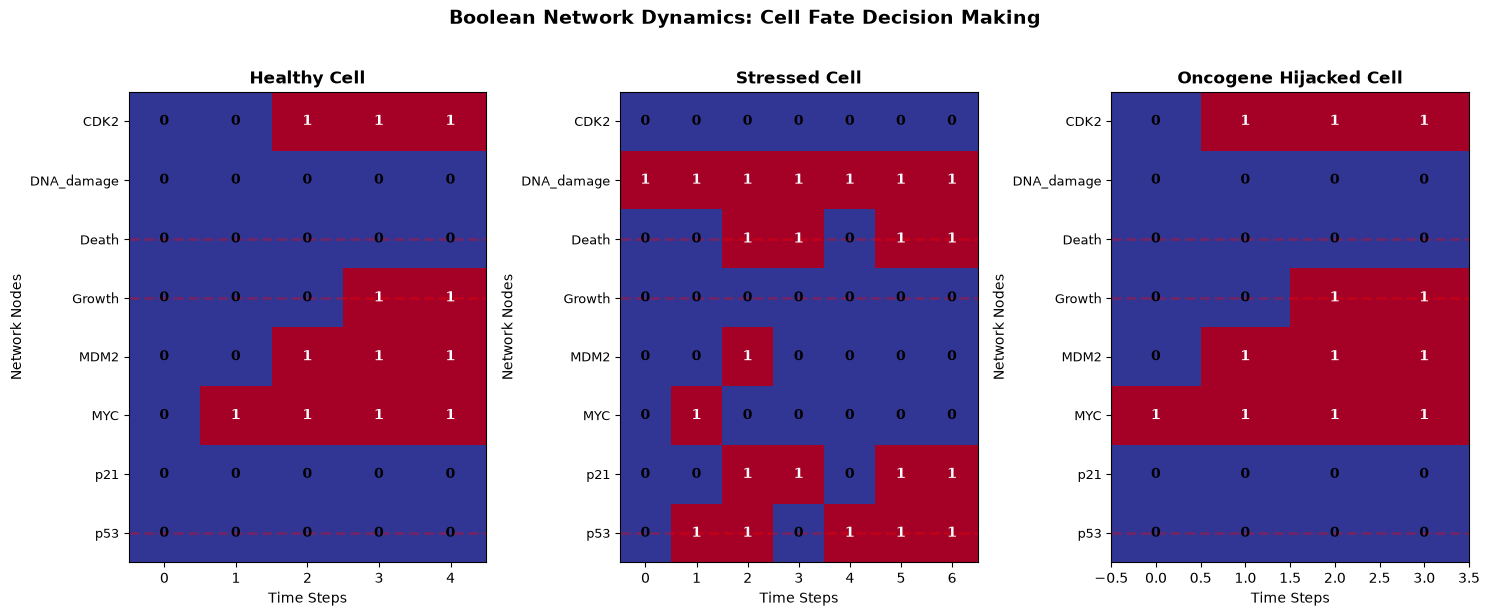

In [11]:
# 🟢 Visualize results
n_scenarios = len(results)
fig, axes = plt.subplots(1, n_scenarios, figsize=(5*n_scenarios, 6))

if n_scenarios == 1:
    axes = [axes]

for scenario_idx, (scenario_name, trajectory) in enumerate(results.items()):
    ax = axes[scenario_idx]

    # Create heatmap
    trajectory_matrix = trajectory.T  # Transpose for proper orientation

    im = ax.imshow(trajectory_matrix, cmap='RdYlBu_r', aspect='auto', interpolation='nearest')

    # Formatting
    ax.set_title(f'{scenario_name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Time Steps', fontsize=10)
    ax.set_ylabel('Network Nodes', fontsize=10)
    ax.set_yticks(range(len(node_names)))
    ax.set_yticklabels(node_names, fontsize=9)

    # Add text annotations
    for t in range(trajectory.shape[0]):
        for n in range(len(node_names)):
            color = 'white' if trajectory_matrix[n, t] == 1 else 'black'
            ax.text(t, n, int(trajectory_matrix[n, t]),
                   ha="center", va="center", color=color, fontweight='bold')

    # Highlight key output nodes
    output_indices = [i for i, name in enumerate(node_names) if name in ['Growth', 'Death', 'p53']]
    for output_idx in output_indices:  # Changed variable name to avoid conflict
        ax.axhline(y=output_idx, color='red', linestyle='--', alpha=0.3, linewidth=2)

plt.suptitle('Boolean Network Dynamics: Cell Fate Decision Making',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Mutation B


In [12]:
nodes = ['DNA_damage', 'p53', 'MYC', 'CDK2',
         'MDM2', 'p21', 'Growth', 'Death']

network_mut_B = BooleanNetwork(nodes)

#MYC always ON
network_mut_B.add_rule('DNA_damage', lambda s: s['DNA_damage'], "DNA_damage = INPUT (constant)")
network_mut_B.add_rule('p21', lambda s: s['p53'], "p21 = p53")
network_mut_B.add_rule('MYC', lambda s: True, "MYC = AMPLIFIED (always ON)")
network_mut_B.add_rule('CDK2', lambda s: s['MYC'] and (not s['p21']) and (not s['p53']), "CDK2 = MYC AND (NOT p21) AND (NOT p53)")
network_mut_B.add_rule('MDM2', lambda s: s['MYC'], "MDM2 = MYC")
network_mut_B.add_rule('p53', lambda s: s['DNA_damage'] and not s['MDM2'], "p53 = DNA_damage AND (NOT MDM2)")
network_mut_B.add_rule('Growth',lambda s: s['CDK2'] and s['MYC'] and (not s['p53']), "Growth = CDK2 AND MYC AND (NOT p53)")
network_mut_B.add_rule('Death', lambda s: s['p53'] and s['DNA_damage'] and (not s['Growth']), "Death = p53 AND DNA_damage AND (NOT Growth)")

print("Mutation B network created")
results_B = run_scenarios(network_mut_B, scenarios,'MYC')

Mutation B network created
   Reached steady state after 4 steps
Healthy Cell: Final state: Growth=1, Death=0, MYC=1
   Reached steady state after 7 steps
Stressed Cell: Final state: Growth=1, Death=0, MYC=1
   Reached steady state after 3 steps
Oncogene Hijacked Cell: Final state: Growth=1, Death=0, MYC=1


In [13]:
from collections import defaultdict
# Attractors for MYC amplification


attractors_B = []
basin_data_B = defaultdict(list)

max_steps = 15

node_names = sorted(network_mut_B.nodes.keys())
n_nodes = len(node_names)

# Generate all 2^8 = 256 possible initial states
all_states = list(product([0, 1], repeat=n_nodes))

print(f"Testing all {len(all_states)} initial states")


for initial_state in all_states:

    # Convert tuple into dictionary
    state_dict = {
        node_names[i]: initial_state[i]
        for i in range(n_nodes)
    }

    # Set initial state
    network_mut_B.set_state(**state_dict)

    # Run simulation
    trajectory = network_mut_B.simulate(
        steps=max_steps,
        record_history=True
    )

    # Check whether we reached a fixed point
    if len(trajectory) >= 2 and np.array_equal(
        trajectory[-1],
        trajectory[-2]
    ):

        final_state = tuple(
            int(x) for x in trajectory[-1]
        )

        # Add attractor if we haven't seen it before
        if final_state not in attractors_B:
            attractors_B.append(final_state)

        # Find attractor number
        att_idx = attractors_B.index(final_state)

        # Save which initial state led to this attractor
        basin_data_B[att_idx].append(initial_state)


print(f"\nFound {len(attractors_B)} attractors")
# Count the states in each basin
print("\nBasin sizes")

total_states = len(all_states)

for att_idx in range(len(attractors_B)):
    basin_size = len(basin_data_B[att_idx])
    percentage = (basin_size / total_states) * 100

    print(
        f"Attractor {att_idx + 1}: "
        f"{basin_size} states ({percentage:.1f}%)"
    )
# Make sure every starting state reached a fixed point
# This also checks that no states were missed because of the step limit
assert sum(len(states) for states in basin_data_B.values()) == total_states

# Count growth with DNA damage and no cell death
cancer_states_B = 0
for att_idx, attractor in enumerate(attractors_B):
    state = dict(zip(node_names, attractor))
    if state['DNA_damage'] == 1 and state['Growth'] == 1 and state['Death'] == 0:
        cancer_states_B += len(basin_data_B[att_idx])

cancer_percentage_B = cancer_states_B / total_states * 100
print(f'Cancer-like growth from {cancer_states_B} of {total_states} states ({cancer_percentage_B:.1f}%)')

Testing all 256 initial states
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 3 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady state after 5 steps
   Reached steady state after 4 steps
   Reached steady s

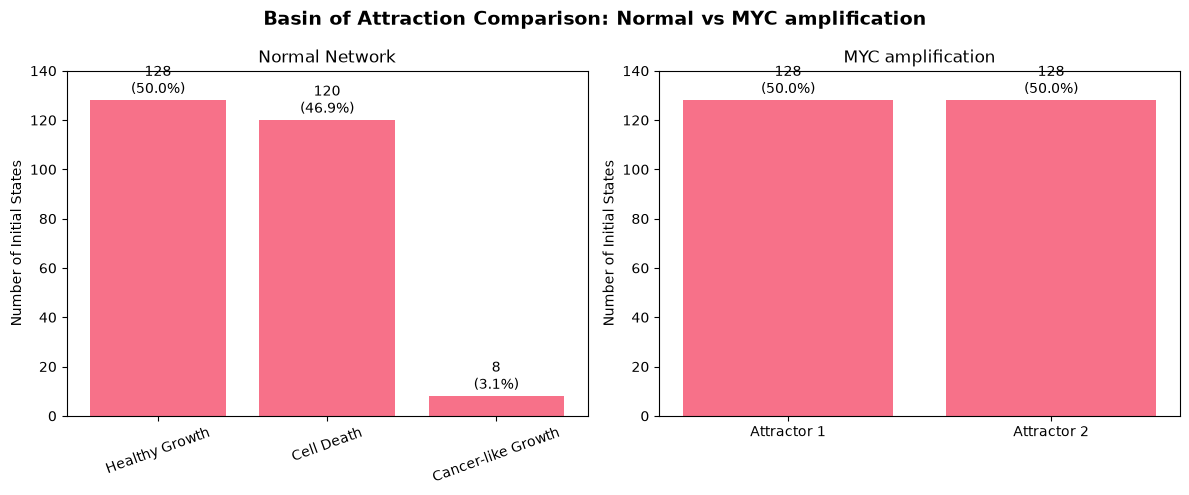

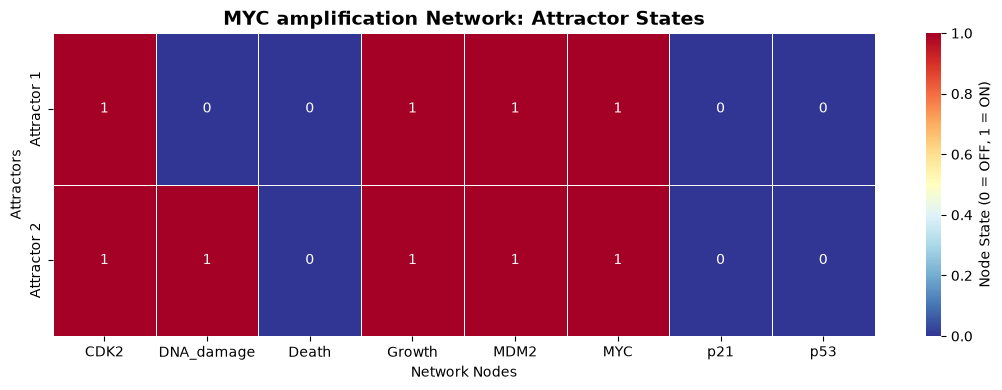

In [14]:
# Compare the basin sizes with the normal network

normal_basin_sizes = [128, 120, 8]
basin_sizes_B = [
    len(basin_data_B[i])
    for i in range(len(attractors_B))
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normal networks
normal_labels = [
    'Healthy Growth',
    'Cell Death',
    'Cancer-like Growth'
]

axes[0].bar(normal_labels, normal_basin_sizes)

axes[0].set_title('Normal Network')
axes[0].set_ylabel('Number of Initial States')
axes[0].set_ylim(0, 140)

for i, value in enumerate(normal_basin_sizes):
    axes[0].text(
        i,
        value + 3,
        f'{value}\n({value / 256 * 100:.1f}%)',
        ha='center'
    )

axes[0].tick_params(axis='x', rotation=20)


# MYC amplification
labels_B = [
    f'Attractor {i+1}'
    for i in range(len(attractors_B))
]

axes[1].bar(labels_B, basin_sizes_B)

axes[1].set_title('MYC amplification')
axes[1].set_ylabel('Number of Initial States')
axes[1].set_ylim(0, 140)

for i, value in enumerate(basin_sizes_B):
    axes[1].text(
        i,
        value + 3,
        f'{value}\n({value / 256 * 100:.1f}%)',
        ha='center'
    )

plt.suptitle(
    'Basin of Attraction Comparison: Normal vs MYC amplification',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Show the node values in each attractor

attractor_matrix_B = np.array([
    [int(x) for x in attractor]
    for attractor in attractors_B
])

plt.figure(figsize=(11, 4))

ax = sns.heatmap(
    attractor_matrix_B,
    xticklabels=node_names,
    yticklabels=[
        f'Attractor {i+1}'
        for i in range(len(attractors_B))
    ],
    cmap='RdYlBu_r',
    annot=True,
    fmt='d',
    linewidths=0.5,
    cbar_kws={
        'label': 'Node State (0 = OFF, 1 = ON)'
    }
)

plt.title(
    'MYC amplification Network: Attractor States',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Network Nodes')
plt.ylabel('Attractors')

plt.tight_layout()
plt.show()

# Mutation B results

MYC stays on and activates MDM2. MDM2 then switches off p53, so p21 also switches off. All three scenarios end with growth on and death off.

There are two attractors with 128 starting states each. Attractor 1 has no DNA damage. Attractor 2 has DNA damage but the cell keeps growing 

The cancer basin is 50% compared with 3.125% in the normal network

# Mutation C

In [15]:
nodes = ['DNA_damage', 'p53', 'MYC', 'CDK2',
         'MDM2', 'p21', 'Growth', 'Death']

network_mut_C = BooleanNetwork(nodes)

#MDM2 always ON
network_mut_C.add_rule('DNA_damage', lambda s: s['DNA_damage'], "DNA_damage = INPUT (constant)")
network_mut_C.add_rule('p21', lambda s: s['p53'], "p21 = p53")
network_mut_C.add_rule('MYC', lambda s: (not s['p53']) and (not s['p21']), "MYC = (NOT p53) AND (NOT p21)")
network_mut_C.add_rule('CDK2', lambda s: s['MYC'] and (not s['p21']) and (not s['p53']), "CDK2 = MYC AND (NOT p21) AND (NOT p53)")
network_mut_C.add_rule('MDM2', lambda s: True, "MDM2 = OVEREXPRESSED (always ON)")
network_mut_C.add_rule('p53', lambda s: s['DNA_damage'] and not s['MDM2'], "p53 = DNA_damage AND (NOT MDM2)")
network_mut_C.add_rule('Growth',lambda s: s['CDK2'] and s['MYC'] and (not s['p53']), "Growth = CDK2 AND MYC AND (NOT p53)")
network_mut_C.add_rule('Death', lambda s: s['p53'] and s['DNA_damage'] and (not s['Growth']), "Death = p53 AND DNA_damage AND (NOT Growth)")

print("Mutation C network created")
results_C = run_scenarios(network_mut_C, scenarios,'MDM2')

Mutation C network created
   Reached steady state after 4 steps
Healthy Cell: Final state: Growth=1, Death=0, MDM2=1
   Reached steady state after 7 steps
Stressed Cell: Final state: Growth=1, Death=0, MDM2=1
   Reached steady state after 3 steps
Oncogene Hijacked Cell: Final state: Growth=1, Death=0, MDM2=1


In [16]:
from collections import defaultdict
# Attractors for MDM2 overexpression


attractors_C = []
basin_data_C = defaultdict(list)

max_steps = 15

node_names = sorted(network_mut_C.nodes.keys())
n_nodes = len(node_names)

# Generate all 2^8 = 256 possible initial states
all_states = list(product([0, 1], repeat=n_nodes))

print(f"Testing all {len(all_states)} initial states")


for initial_state in all_states:

    # Convert tuple into dictionary
    state_dict = {
        node_names[i]: initial_state[i]
        for i in range(n_nodes)
    }

    # Set initial state
    network_mut_C.set_state(**state_dict)

    # Run simulation
    trajectory = network_mut_C.simulate(
        steps=max_steps,
        record_history=True
    )

    # Check whether we reached a fixed point
    if len(trajectory) >= 2 and np.array_equal(
        trajectory[-1],
        trajectory[-2]
    ):

        final_state = tuple(
            int(x) for x in trajectory[-1]
        )

        # Add attractor if we haven't seen it before
        if final_state not in attractors_C:
            attractors_C.append(final_state)

        # Find attractor number
        att_idx = attractors_C.index(final_state)

        # Save which initial state led to this attractor
        basin_data_C[att_idx].append(initial_state)


print(f"\nFound {len(attractors_C)} attractors")
# Count the states in each basin
print("\nBasin sizes")

total_states = len(all_states)

for att_idx in range(len(attractors_C)):
    basin_size = len(basin_data_C[att_idx])
    percentage = (basin_size / total_states) * 100

    print(
        f"Attractor {att_idx + 1}: "
        f"{basin_size} states ({percentage:.1f}%)"
    )
# Make sure every starting state reached a fixed point
# This also checks that no states were missed because of the step limit
assert sum(len(states) for states in basin_data_C.values()) == total_states

# Count growth with DNA damage and no cell death
cancer_states_C = 0
for att_idx, attractor in enumerate(attractors_C):
    state = dict(zip(node_names, attractor))
    if state['DNA_damage'] == 1 and state['Growth'] == 1 and state['Death'] == 0:
        cancer_states_C += len(basin_data_C[att_idx])

cancer_percentage_C = cancer_states_C / total_states * 100
print(f'Cancer-like growth from {cancer_states_C} of {total_states} states ({cancer_percentage_C:.1f}%)')

Testing all 256 initial states
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady s

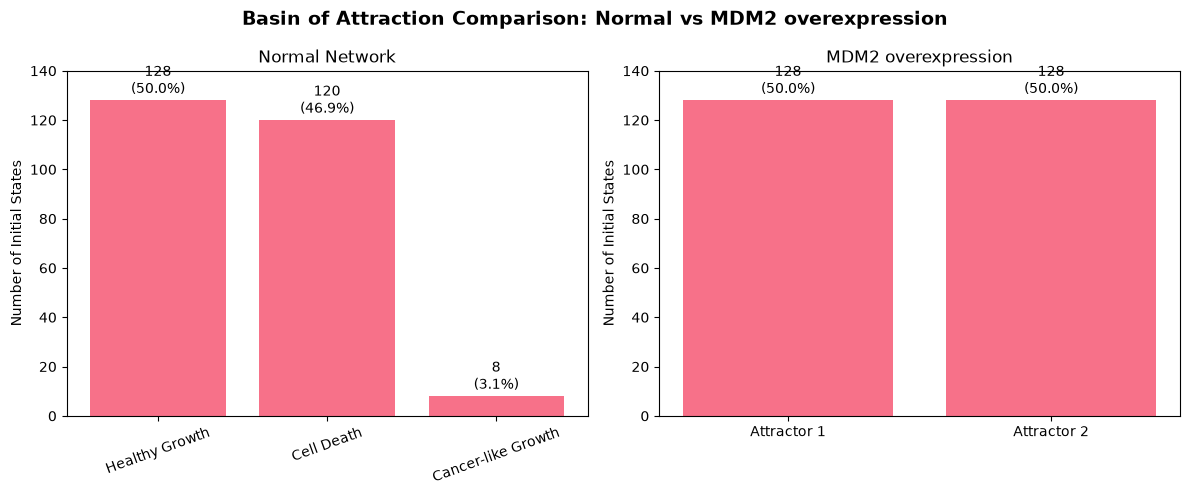

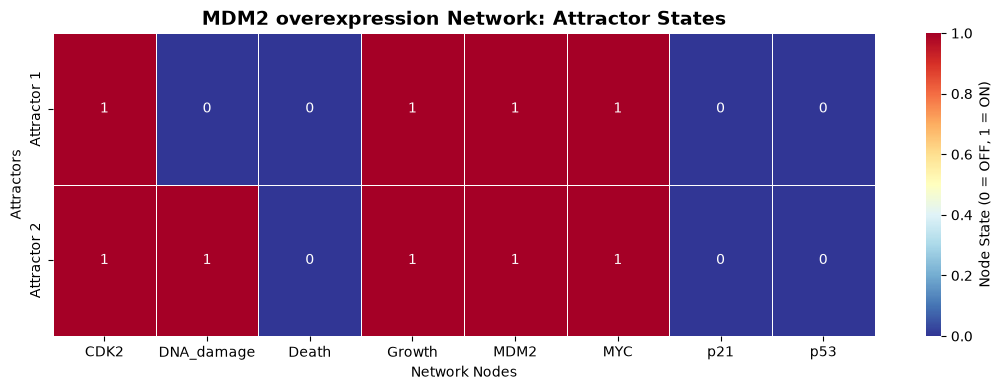

In [17]:
# Compare the basin sizes with the normal network

normal_basin_sizes = [128, 120, 8]
basin_sizes_C = [
    len(basin_data_C[i])
    for i in range(len(attractors_C))
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normal networks
normal_labels = [
    'Healthy Growth',
    'Cell Death',
    'Cancer-like Growth'
]

axes[0].bar(normal_labels, normal_basin_sizes)

axes[0].set_title('Normal Network')
axes[0].set_ylabel('Number of Initial States')
axes[0].set_ylim(0, 140)

for i, value in enumerate(normal_basin_sizes):
    axes[0].text(
        i,
        value + 3,
        f'{value}\n({value / 256 * 100:.1f}%)',
        ha='center'
    )

axes[0].tick_params(axis='x', rotation=20)


# MDM2 overexpression
labels_C = [
    f'Attractor {i+1}'
    for i in range(len(attractors_C))
]

axes[1].bar(labels_C, basin_sizes_C)

axes[1].set_title('MDM2 overexpression')
axes[1].set_ylabel('Number of Initial States')
axes[1].set_ylim(0, 140)

for i, value in enumerate(basin_sizes_C):
    axes[1].text(
        i,
        value + 3,
        f'{value}\n({value / 256 * 100:.1f}%)',
        ha='center'
    )

plt.suptitle(
    'Basin of Attraction Comparison: Normal vs MDM2 overexpression',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Show the node values in each attractor

attractor_matrix_C = np.array([
    [int(x) for x in attractor]
    for attractor in attractors_C
])

plt.figure(figsize=(11, 4))

ax = sns.heatmap(
    attractor_matrix_C,
    xticklabels=node_names,
    yticklabels=[
        f'Attractor {i+1}'
        for i in range(len(attractors_C))
    ],
    cmap='RdYlBu_r',
    annot=True,
    fmt='d',
    linewidths=0.5,
    cbar_kws={
        'label': 'Node State (0 = OFF, 1 = ON)'
    }
)

plt.title(
    'MDM2 overexpression Network: Attractor States',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Network Nodes')
plt.ylabel('Attractors')

plt.tight_layout()
plt.show()

# Mutation C results

MDM2 stays on and switches off p53. This also switches off p21, allowing MYC and CDK2 to drive growth. All three scenarios end with growth on and death off.

There are two attractors with 128 starting states each. Attractor 1 has no DNA damage. Attractor 2 has DNA damage but the cell keeps growing

The cancer-like basin is 50% compared with 3.125% in the normal network.

❓ **Question**: Were your predictions for each scenario correct?
1. Which scenario leads to cell growth? Healthy cell and oncogene hijacked cell
2. Which scenario leads to cell death? Stressed cell
3. How does p53 affect MYC? p53 inhibites MYC
4. What happens when there's no DNA damage? p53 stays off , so MYC stays active and cell continues to grow


---

## **Part 3: Attractor analysis**

Attractors = stable states the network eventually reaches from any starting oint

Types:
* Fixed Point: Network stops changing (steady state)
* Limit Cycle: Network oscillates in repeating pattern  

Why is this important?
* Represent system's natural 'destinations'
* Can predict long-term behavior
* Identify stable patterns in system
* Design interventions to reach desired attractors

In [18]:
# 🟡 Let's find the attractor states
import itertools
attractors = []
max_steps=15
node_names = sorted(network.nodes.keys())
n_nodes = len(node_names)

print(f"Testing all {2**n_nodes} possible initial states...")

# TODO: Generate all possible initial states
# Hint: Use itertools.product([0, 1], repeat=n_nodes)
all_states = itertools.product([0, 1], repeat=n_nodes)

for initial_state in all_states:
  # Set the network to this initial state
  state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
  network.set_state(**state_dict)

  # TODO: Simulate the network
  trajectory = network.simulate(steps=max_steps)

  # Check if it reached a steady state (last two states are the same)
  if len(trajectory) >= 2:
    final_state = tuple(trajectory[-1])  # Convert to tuple for comparison

  # Check if this is a new attractor
    if np.array_equal(trajectory[-1], trajectory[-2]):  # Steady state reached
      if final_state not in attractors:
        attractors.append(final_state)

Testing all 256 possible initial states...
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reac

❓ **Questions and interpretation**
1. How many total states did we test? 2^8 = 256
2. Why does the number of states grow so quickly? as each node can be either 0 or 1, so every node doubles number of possible states
3. What would happen if we had 15 nodes instead of 8? we would have 32168 states, the simulation will take much more time


---


FOUND 3 ATTRACTORS:

Attractor 1: [np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
   Growth: ON
   Death: OFF
   p53: OFF
   DNA Damage: OFF
   → Cell is growing normally - healthy growth

Attractor 2: [np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1)]
   Growth: OFF
   Death: ON
   p53: ON
   DNA Damage: ON
   → cell death

Attractor 3: [np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
   Growth: ON
   Death: OFF
   p53: OFF
   DNA Damage: ON
   → uncontrolled growth


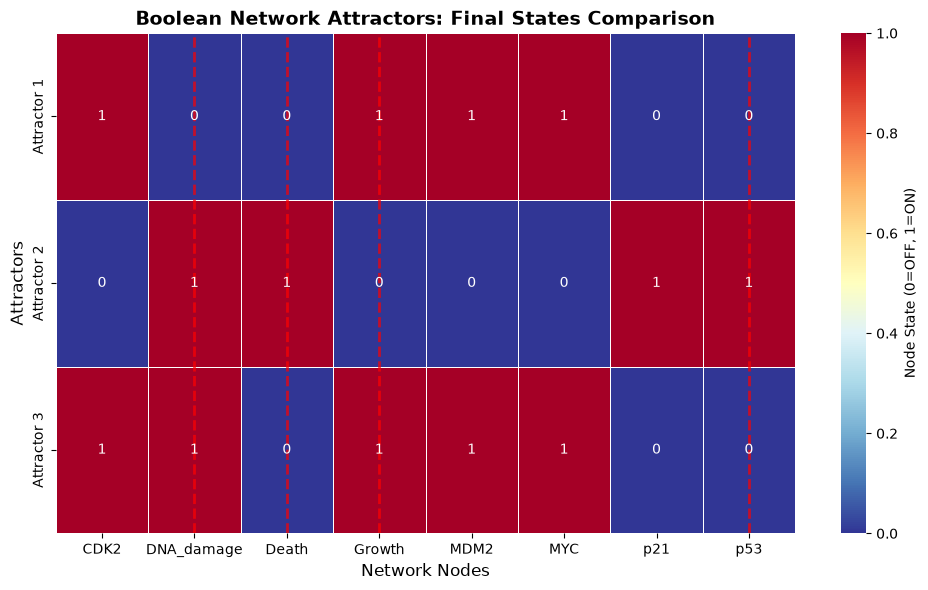

In [19]:
# 🟡 Let's find the attractor states

print(f"\nFOUND {len(attractors)} ATTRACTORS:")

for i, attractor in enumerate(attractors):
        print(f"\nAttractor {i+1}: {list(attractor)}")

        # Create state dictionary for easy access
        state_dict = {node_names[j]: attractor[j] for j in range(len(node_names))}

        # Analyze the biological meaning
        growth_active = state_dict['Growth'] == 1
        death_active = state_dict['Death'] == 1
        p53_active = state_dict['p53'] == 1
        dna_damage_active = state_dict['DNA_damage'] == 1


        print(f"   Growth: {'ON' if growth_active else 'OFF'}")
        print(f"   Death: {'ON' if death_active else 'OFF'}")
        print(f"   p53: {'ON' if p53_active else 'OFF'}")
        print(f"   DNA Damage: {'ON' if dna_damage_active else 'OFF'}")

        # TODO: Interpret the meaning
        if growth_active and not death_active and not dna_damage_active:
            interpretation = "Cell is growing normally - healthy growth"
        elif death_active and not growth_active:
            interpretation = "cell death"
        elif growth_active and not death_active and dna_damage_active:
            interpretation = "uncontrolled growth"
        else:
            interpretation = "CONFLICT - Unusual state"

        print(f"   → {interpretation}")


# Convert attractors to clean matrix
attractor_matrix = []
for attractor in attractors:
    clean_row = [int(x) for x in attractor]
    attractor_matrix.append(clean_row)

attractor_matrix = np.array(attractor_matrix)

# Create heatmap
plt.figure(figsize=(10, max(6, len(attractors))))

# Create heatmap with custom colors
ax = sns.heatmap(attractor_matrix,
                 xticklabels=node_names,
                 yticklabels=[f'Attractor {i+1}' for i in range(len(attractors))],
                 cmap='RdYlBu_r',
                 cbar_kws={'label': 'Node State (0=OFF, 1=ON)'},
                 annot=True,
                 fmt='d',
                 linewidths=0.5)

plt.title('Boolean Network Attractors: Final States Comparison',
          fontsize=14, fontweight='bold')
plt.xlabel('Network Nodes', fontsize=12)
plt.ylabel('Attractors', fontsize=12)

# Highlight key output nodes
output_nodes = ['Growth', 'Death', 'p53', 'DNA_damage']
for node in output_nodes:
    if node in node_names:
        idx = node_names.index(node)
        ax.axvline(x=idx+0.5, color='red', linestyle='--', alpha=0.7, linewidth=2)

plt.tight_layout()
plt.show()

❓ **Questions and interpretation**
1. How many attractors did we find? 3 attractors
2. What does each attractor represent biologically?
    -Attractor 1: normal/healthy growth — Growth ON, Death OFF, DNA damage OFF.
    -Attractor 2: cell death — Growth OFF, Death ON, p53 ON, DNA damage ON.
    -Attractor 3: uncontrolled growth despite DNA damage — Growth ON, Death OFF, DNA damage ON, p53 OFF.
4. Which attractor represents a 'healthy' cell state(attractor 1) and which one a cancerous' cell state(attractor 3)?



---





Analyzing 256 initial states...
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady 

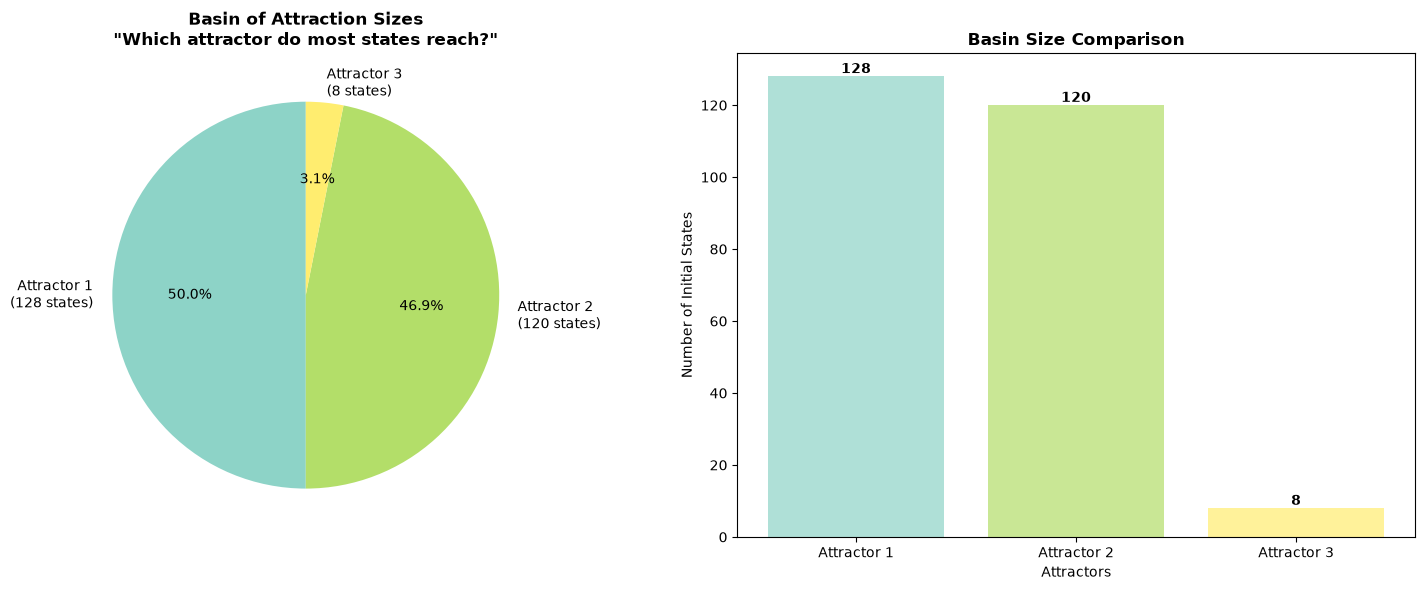

In [20]:
# 🟡 Which states end up in which attractor?

# Track which initial states lead to which attractors
basin_data = defaultdict(list)  # attractor -> list of initial states
attractor_map = {}  # initial_state -> attractor_index

n_nodes = len(node_names)
all_states = list(product([0, 1], repeat=n_nodes))
print(f"Analyzing {len(all_states)} initial states...")

for initial_state in all_states:
    # Set network state
    state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
    network.set_state(**state_dict)

    # Simulate
    trajectory = network.simulate(steps=max_steps, record_history=True)

    # Find which attractor this leads to
    if len(trajectory) >= 2 and np.array_equal(trajectory[-1], trajectory[-2]):
        final_state = tuple(int(x) for x in trajectory[-1])  # Clean conversion

        # Find matching attractor
        for att_idx, attractor in enumerate(attractors):
            clean_attractor = tuple(int(x) for x in attractor)
            if final_state == clean_attractor:
                basin_data[att_idx].append(initial_state)
                attractor_map[initial_state] = att_idx
                break

# Display basin sizes
print(f"\n Basin Sizes:")
total_states = len(all_states)
for att_idx in range(len(attractors)):
    basin_size = len(basin_data[att_idx])
    percentage = (basin_size / total_states) * 100
    print(f"   Attractor {att_idx+1}: {basin_size:3d} states ({percentage:5.1f}%)")

# Create pie chart of basin sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart of basin sizes
basin_sizes = [len(basin_data[i]) for i in range(len(attractors))]
basin_labels = [f'Attractor {i+1}\n({size} states)' for i, size in enumerate(basin_sizes)]
colors = plt.cm.Set3(np.linspace(0, 1, len(attractors)))

wedges, texts, autotexts = ax1.pie(basin_sizes,
                                   labels=basin_labels,
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=90)

ax1.set_title('Basin of Attraction Sizes\n"Which attractor do most states reach?"',
              fontsize=12, fontweight='bold')

# Bar chart comparison
attractor_names = [f'Attractor {i+1}' for i in range(len(attractors))]
bars = ax2.bar(attractor_names, basin_sizes, color=colors, alpha=0.7)

ax2.set_title('Basin Size Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Initial States', fontsize=10)
ax2.set_xlabel('Attractors', fontsize=10)

# Add value labels on bars
for bar, size in zip(bars, basin_sizes):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{size}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

❓ **Questions and interpretation**
* How many initial states lead to each attractor? A1 - 128, A2 - 120, A3 - 8
* Which attractors are most "popular" (large basins)? A1 and A2





### Comparison of normal and mutated networks

Mutation D is now **p21 knockout**, applied independently to the normal network. It replaces the earlier CDK2/Growth custom model. The assignment comparison contains Normal and mutations A–D.

| Network | Healthy | Stressed | Oncogene initial condition | Fixed points | Cycles | Cancer-like basin |
| --- | --- | --- | --- | ---: | ---: | ---: |
| Normal | Growth | Death | Growth | 3 | 0 | 8/256 (3.125%) |
| A: p53 knockout | Growth | Growth | Growth | 2 | 0 | 128/256 (50%) |
| B: MYC amplification | Growth | Growth | Growth | 2 | 0 | 128/256 (50%) |
| C: MDM2 overexpression | Growth | Growth | Growth | 2 | 0 | 128/256 (50%) |
| D: p21 knockout | Growth | Period-3 cycle | Growth | 3 | 2 | 8/256 (3.125%) |

A point is cancer-like if DNA_damage=1, Growth=1 and Death=0. The main cycle-level metric requires this in **every** phase; the calculated table also reports an **any-phase** metric. Neither D cycle has Growth ON, so both metrics agree for these networks. All percentages use all 256 initial states as the denominator.

A, B and C tie at a 50% cancer-like basin, 16 times the normal value. D has the same cancer-like percentage as normal but different attractors and basin sizes: 96/256 states (37.5%) reach cycles. These fractions describe equally weighted model states, not measured cancer probabilities.

## Mutation D: p21 knockout

The custom mutation removes p21 activity by replacing only its update rule with `p21 = False`. All other rules, including the normal CDK2 and Growth rules, remain unchanged. This removes p21's inhibition of MYC and CDK2 while retaining their direct inhibition by p53.

In [21]:
# Mutation D: p21 knockout only, based on the normal network.
p21_KO_network = BooleanNetwork(list(network.nodes))
for target, info in network.rules.items():
    p21_KO_network.add_rule(target, info['function'], info['description'])
p21_KO_network.add_rule('p21', lambda s: False, 'p21 = KNOCKOUT (always OFF after update)')
network_mut_D = p21_KO_network

### Analysis conventions

We retain the practical's initial scenarios and enumerate all 256 binary initial states. The constant mutation rule applies from the first update. The scenario initial states already have p21=0; the exhaustive enumeration also includes p21=1 at time zero.

Because D has cycles, the analysis tracks previously visited states until a recurrence instead of testing only whether the last two states match. Each cycle is rotated into a canonical order for identification. Its first phase is not a final state. In outcome strings, G means Growth and D means the Death output.

In [22]:
from itertools import product
from collections import Counter


def trace_to_attractor(model, initial):
    """Return a canonical cycle and the actual path through first recurrence."""
    names = sorted(model.nodes)
    state = tuple(int(initial[name]) for name in names)
    seen, path = {}, []
    while state not in seen:
        seen[state] = len(path)
        path.append(state)
        current = dict(zip(names, state))
        state = tuple(int(model.rules[name]['function'](current))
                      if name in model.rules else current[name] for name in names)
    cycle = tuple(path[seen[state]:])
    canonical = min(cycle[i:] + cycle[:i] for i in range(len(cycle)))
    return canonical, path + [state]


def enumerate_basins(model):
    names = sorted(model.nodes)
    basins = Counter()
    max_updates = 0
    for point in product([0, 1], repeat=len(names)):
        cycle, path = trace_to_attractor(model, dict(zip(names, point)))
        basins[cycle] += 1
        max_updates = max(max_updates, len(path) - 1)
    assert sum(basins.values()) == 2 ** len(names)
    return names, basins, max_updates


def is_cancer_like(names, point):
    s = dict(zip(names, point))
    return s['DNA_damage'] == 1 and s['Growth'] == 1 and s['Death'] == 0


def describe_attractor(names, cycle):
    phases = []
    for point in cycle:
        s = dict(zip(names, point))
        phases.append(f"(G={s['Growth']}, D={s['Death']}, p53={s['p53']})")
    if len(cycle) == 1:
        return 'Fixed point: ' + phases[0]
    return f'Period-{len(cycle)} cycle: ' + ' → '.join(phases) + ' → repeat'


comparison_models = {
    'Normal': network,
    'A: p53 knockout': p53_KO_network,
    'B: MYC amplification': network_mut_B,
    'C: MDM2 overexpression': network_mut_C,
    'D: p21 knockout': p21_KO_network,
}
exact_analyses = {}
comparison_rows, scenario_rows, attractor_rows_D = [], [], []
scenario_cycles, scenario_paths = {}, {}
for label, model in comparison_models.items():
    names, basins, max_updates = enumerate_basins(model)
    exact_analyses[label] = (names, basins, max_updates)
    total = sum(basins.values())
    cancer_count = sum(size for cycle, size in basins.items()
                       if all(is_cancer_like(names, point) for point in cycle))
    any_cancer_count = sum(size for cycle, size in basins.items()
                           if any(is_cancer_like(names, point) for point in cycle))
    cyclic_count = sum(size for cycle, size in basins.items() if len(cycle) > 1)
    comparison_rows.append({
        'Network': label,
        'Fixed points': sum(len(cycle) == 1 for cycle in basins),
        'Cycles': sum(len(cycle) > 1 for cycle in basins),
        'Total attractors': len(basins),
        'Cancer-like states': cancer_count, 'Total states': total,
        'Cancer-like Basin (%)': 100 * cancer_count / total,
        'Any-phase cancer-like (%)': 100 * any_cancer_count / total,
        'Cyclic basin (%)': 100 * cyclic_count / total,
    })
    for scenario, initial in scenarios.items():
        cycle, path = trace_to_attractor(model, initial)
        scenario_cycles[label, scenario] = cycle
        scenario_paths[label, scenario] = path
        scenario_rows.append({'Network': label, 'Scenario': scenario,
                              'Outcome': describe_attractor(names, cycle)})

names_D, basins_D, max_updates_D = exact_analyses['D: p21 knockout']
for index, (cycle, size) in enumerate(basins_D.items(), 1):
    for phase, point in enumerate(cycle, 1):
        attractor_rows_D.append({
            'Attractor': f'D{index}', 'Period': len(cycle), 'Phase': phase,
            'Basin size': size, 'Basin (%)': 100 * size / sum(basins_D.values()),
            **dict(zip(names_D, point)),
        })
comparison_df = pd.DataFrame(comparison_rows)
scenario_df = pd.DataFrame(scenario_rows)
attractor_df_D = pd.DataFrame(attractor_rows_D)
print('Calculated comparison (persistent cancer-like definition):')
print(comparison_df.to_string(index=False))
print('\nScenario outcomes:')
print(scenario_df.to_string(index=False))
print('\nFull D attractor states. Basin sizes repeat by phase; do not sum phase rows:')
print(attractor_df_D.to_string(index=False))
print(f'\nD: all 256 states accounted for; at most {max_updates_D} updates to first recurrence.')

Calculated comparison (persistent cancer-like definition):
               Network  Fixed points  Cycles  Total attractors  Cancer-like states  Total states  Cancer-like Basin (%)  Any-phase cancer-like (%)  Cyclic basin (%)
                Normal             3       0                 3                   8           256                  3.125                      3.125               0.0
       A: p53 knockout             2       0                 2                 128           256                 50.000                     50.000               0.0
  B: MYC amplification             2       0                 2                 128           256                 50.000                     50.000               0.0
C: MDM2 overexpression             2       0                 2                 128           256                 50.000                     50.000               0.0
       D: p21 knockout             3       2                 5                   8           256                  3.

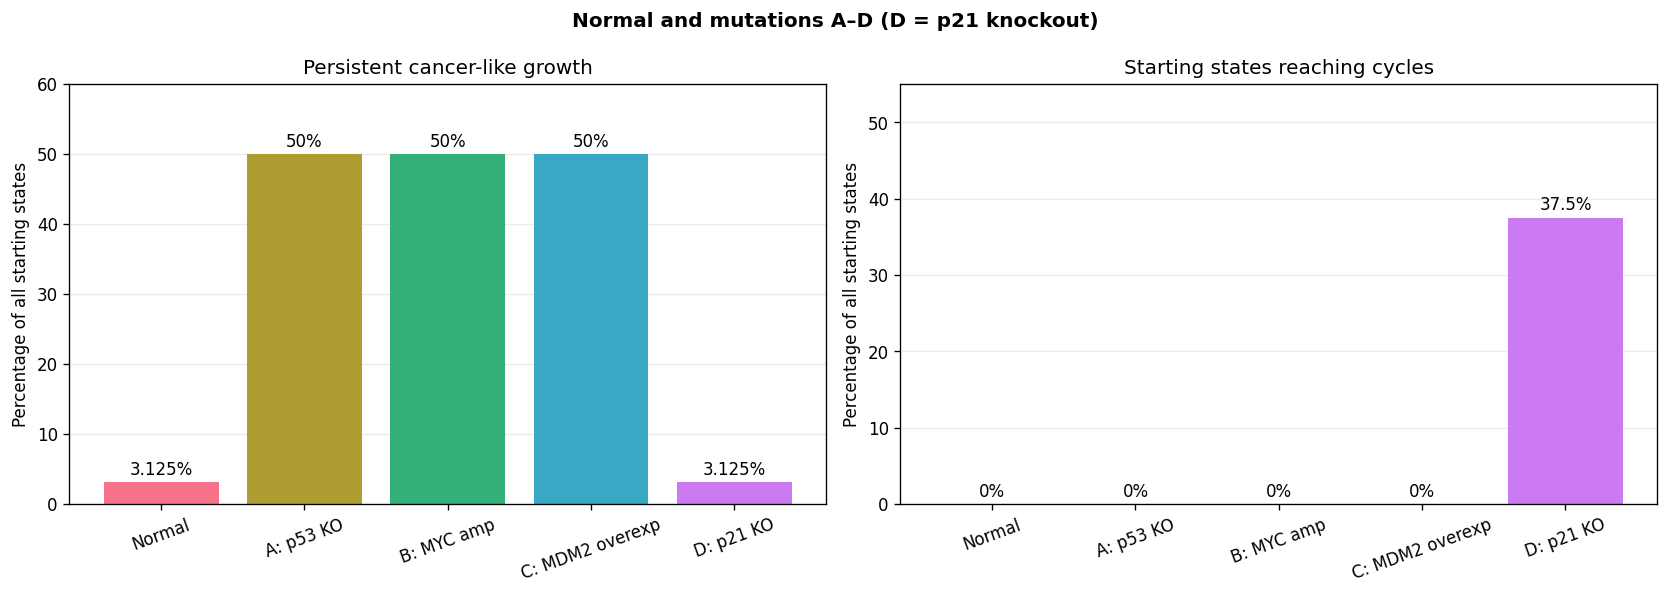

In [23]:
# Both plots use calculated results for Normal and mutations A–D.
labels = ['Normal', 'A: p53 KO', 'B: MYC amp', 'C: MDM2 overexp', 'D: p21 KO']
colors = sns.color_palette('husl', n_colors=len(labels))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, column, title in [
    (axes[0], 'Cancer-like Basin (%)', 'Persistent cancer-like growth'),
    (axes[1], 'Cyclic basin (%)', 'Starting states reaching cycles'),
]:
    values = comparison_df[column].to_numpy()
    bars = ax.bar(labels, values, color=colors)
    ax.set_title(title)
    ax.set_ylabel('Percentage of all starting states')
    ax.set_ylim(0, max(55, float(values.max()) + 10))
    ax.tick_params(axis='x', labelrotation=20)
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 1,
                f'{value:g}%', ha='center')
fig.suptitle('Normal and mutations A–D (D = p21 knockout)', fontweight='bold')
plt.tight_layout()
plt.show()

### Mutation D results and interpretation

| Initial scenario | Attractor outcome |
| --- | --- |
| Healthy Cell | Fixed point: Growth=1, Death=0, p53=0 |
| Stressed Cell | Period-3 cycle: (Growth, Death, p53) = (0,0,1) → (0,1,1) → (0,1,0) → repeat |
| Oncogene Hijacked Cell | Fixed point: Growth=1, Death=0, p53=0 |

| D attractor | Type | Basin size | Percentage of all 256 states |
| --- | --- | ---: | ---: |
| D1: growth without DNA damage | Fixed point | 128 | 50% |
| D2: cycle 1 | Period 3 | 56 | 21.875% |
| D3: death with DNA damage | Fixed point | 24 | 9.375% |
| D4: cycle 2 | Period 3 | 40 | 15.625% |
| D5: cancer-like growth | Fixed point | 8 | 3.125% |

D has **five attractors: three fixed points and two period-3 cycles**. The two cyclic basins contain 96/256 states (37.5%). Neither cycle has Growth ON, so both the persistent and any-phase cancer-like metrics give 8/256 = 3.125%.

Removing p21 changes the inhibitory feedback involving MYC and CDK2 while retaining direct p53 inhibition. The normal network's damaged death basin has 120 states; for D the death fixed-point basin has 24 states and the cyclic basins have 96 in total. The full death fixed point also differs from normal because p21 is forced OFF.

The model's Death output can turn ON and OFF. This reflects the absence of an irreversible-death mechanism; it is not evidence that a real cell dies and revives. Cycles here are results of the specified synchronous Boolean rules, not experimentally validated biological oscillations.

**Conclusion:** A–C tie at 50% under the cancer-like basin metric. D retains the normal value of 3.125%, but changes the dynamics substantially. Cancer-like percentage alone does not capture those changes.

## Mutation D: comparison with normal and attractor heatmap

The charts compare every attractor basin separately. D's heatmap includes **all nine recurrent states**: one row for each of its three fixed points and three rows for each of its two cycles. The D1–D5 identifiers match the table above; phases in each cycle follow the transition order, up to the arbitrary choice of starting phase.

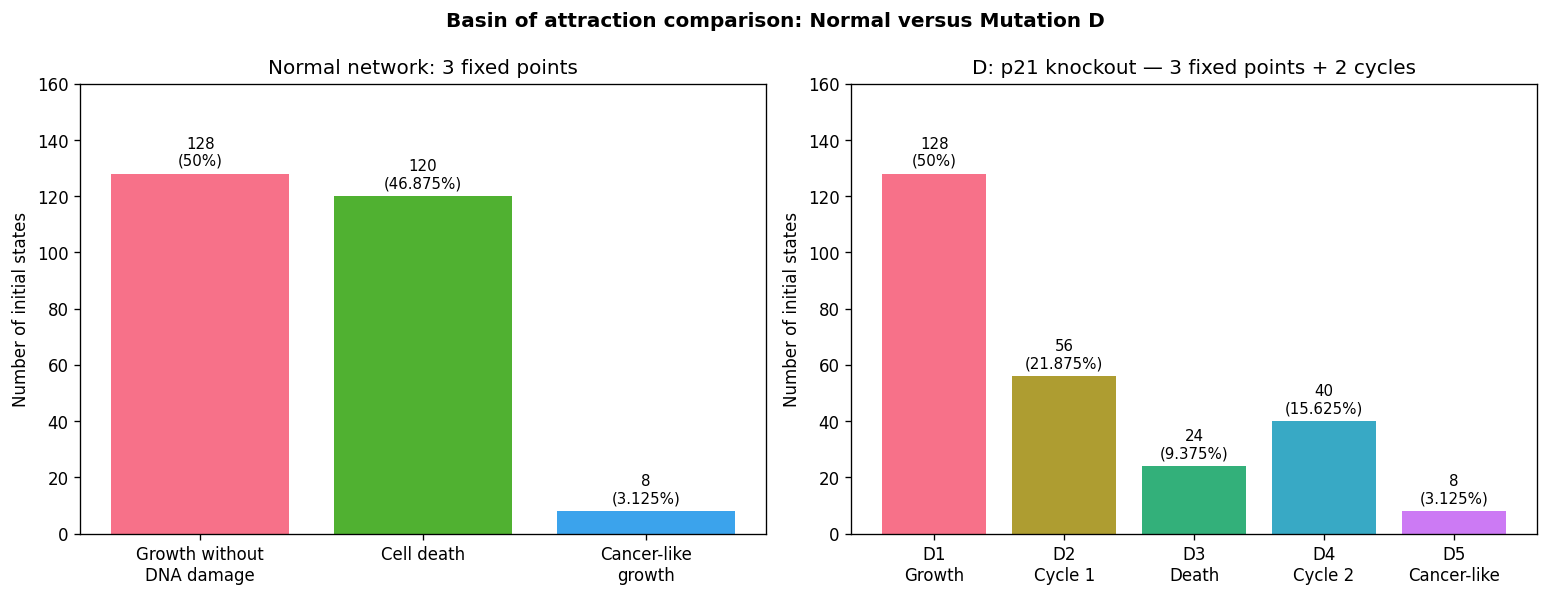

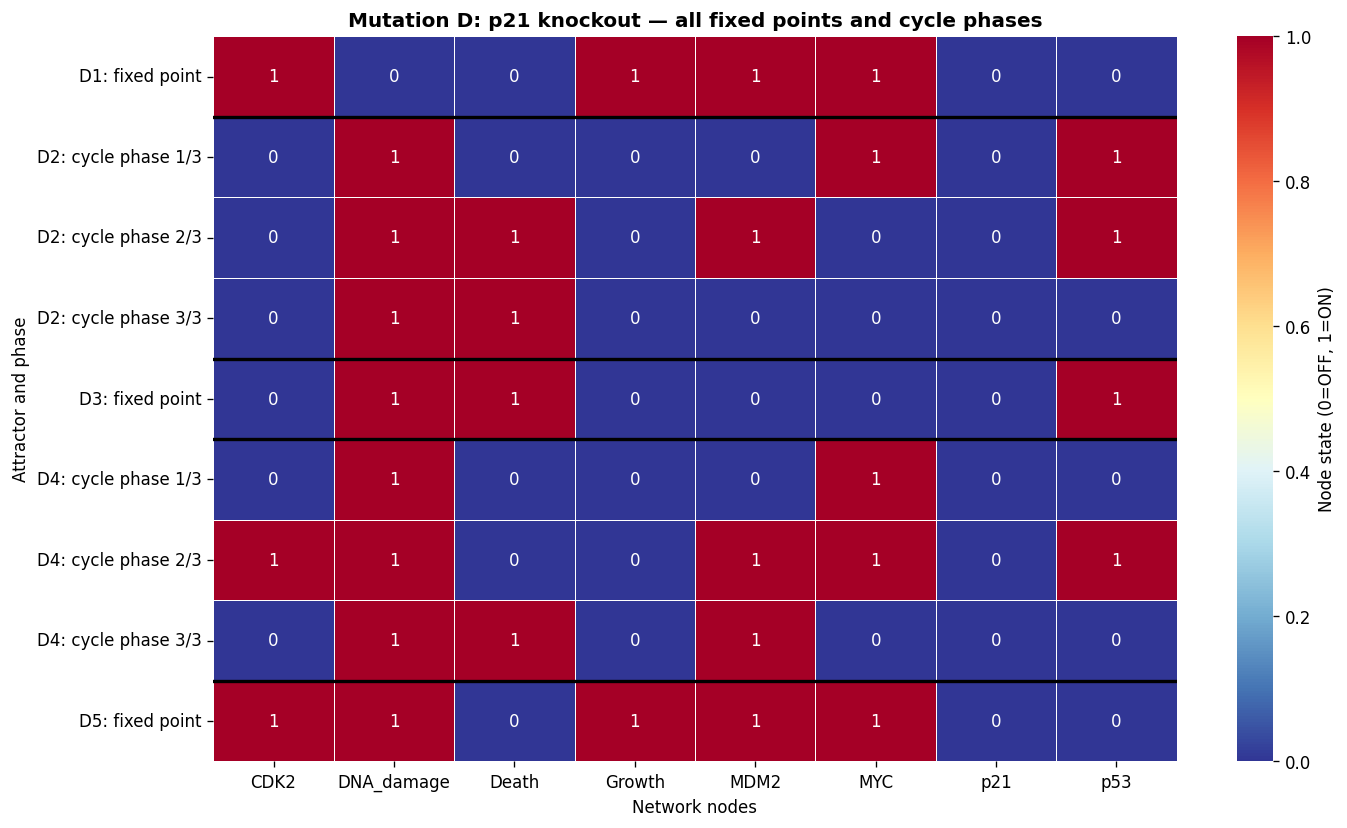

In [24]:
# Compare all basin sizes, including D's two cycles.
normal_names_for_D, normal_cycles_for_D, _ = exact_analyses['Normal']
normal_basin_sizes_for_D = list(normal_cycles_for_D.values())
basin_sizes_D = list(basins_D.values())
normal_labels_for_D = ['Growth without\nDNA damage', 'Cell death', 'Cancer-like\ngrowth']
labels_D = ['D1\nGrowth', 'D2\nCycle 1', 'D3\nDeath', 'D4\nCycle 2', 'D5\nCancer-like']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, title, labels, sizes in [
    (axes[0], 'Normal network: 3 fixed points', normal_labels_for_D, normal_basin_sizes_for_D),
    (axes[1], 'D: p21 knockout — 3 fixed points + 2 cycles', labels_D, basin_sizes_D),
]:
    bars = ax.bar(labels, sizes, color=sns.color_palette('husl', len(sizes)))
    ax.set_title(title)
    ax.set_ylabel('Number of initial states')
    ax.set_ylim(0, max(normal_basin_sizes_for_D + basin_sizes_D) * 1.25)
    for bar, size in zip(bars, sizes):
        ax.text(bar.get_x() + bar.get_width() / 2, size + 3,
                f'{size}\n({100 * size / sum(sizes):g}%)', ha='center', fontsize=9)
fig.suptitle('Basin of attraction comparison: Normal versus Mutation D', fontweight='bold')
plt.tight_layout()
plt.show()

# Show every phase; never collapse a cycle to its first state.
attractor_matrix_D = np.array([point for cycle in basins_D for point in cycle], dtype=int)
heatmap_labels_D, boundaries_D = [], []
row_count = 0
for i, cycle in enumerate(basins_D, 1):
    for phase in range(1, len(cycle) + 1):
        heatmap_labels_D.append(f'D{i}: fixed point' if len(cycle) == 1
                                else f'D{i}: cycle phase {phase}/{len(cycle)}')
    row_count += len(cycle)
    boundaries_D.append(row_count)
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(attractor_matrix_D, xticklabels=names_D, yticklabels=heatmap_labels_D,
            cmap='RdYlBu_r', vmin=0, vmax=1, annot=True, fmt='d', linewidths=0.5,
            cbar_kws={'label': 'Node state (0=OFF, 1=ON)'}, ax=ax)
for boundary in boundaries_D[:-1]:
    ax.axhline(boundary, color='black', linewidth=2)
ax.set_title('Mutation D: p21 knockout — all fixed points and cycle phases', fontweight='bold')
ax.set_xlabel('Network nodes')
ax.set_ylabel('Attractor and phase')
plt.tight_layout()
plt.show()